# **Instituto Tecnológico y de Estudios Superiores de Monterrey**
## **Maestría en Inteligencia Artificial Aplicada**
### **Proyecto integrador (TC5035.10)**
### **Algoritmos de regresión de Machine Learning para la estimación del carbono en bosques mezclados de Durango**
#### **Avance 4. Modelos alternativos**
#### **Dra. Maria Valentina Narváez Teran**

##### Gerónimo Quiñónez Barraza – A01795904  
##### Alfredo Rigoberto Álvarez Suárez – A01796142  
##### Humberto Alonso Torres Hernández – A01793682  


## Introducción y marco metodológico

El presente desarrollo forma parte del marco de investigación del proyecto integrador, cuyo objetivo primordial es el diseño, evaluación y validación de modelos predictivos avanzados basados en Machine Learning para estimar la densidad de los almacenes de carbono aéreo ($CO2eA$, expresado en $tCO2e/ha$) en los ecosistemas forestales mezclados del estado de Durango, México.

La cuantificación precisa del carbono forestal representa un pilar crítico en las estrategias globales de mitigación del cambio climático y en los mercados de bonos de carbono. Tradicionalmente, estas estimaciones dependen de inventarios forestales físicos extenuantes y de alto costo. Este notebook aborda el problema mediante un enfoque de **sensores remotos pasivos**, utilizando firmas e índices espectrales satelitales (como *NDMI*, *NBR*, *MSI*) acoplados a variables topográficas estructuradas (como la *elevación* y *pendiente*).

### Objetivos experimentales de este avance:
1. **Evaluación de Modelos Candidatos Alternativos:** Implementar y comparar sistemáticamente seis arquitecturas individuales de regresión bajo las mismas condiciones de frontera: regresiones paramétricas con regularización (*Ridge*, *Lasso*, *Elastic Net*), regresión lineal clásica ordinaria (`LinearRegression`), el modelo no paramétrico basado en distancias espaciales de características (`KNeighborsRegressor`) y modelos de segmentación jerárquica (`DecisionTreeRegressor`).
2. **Preprocesamiento Robusto:** Garantizar que no exista sesgo dimensional ni fuga de datos (*data leakage*) mediante el uso de un pipeline automatizado de escalamiento de características (`MinMaxScaler`).
3. **Optimización Avanzada de Hiperparámetros:** Someter a los algoritmos con mayor potencial predictivo a una búsqueda exhaustiva por rejilla (`GridSearchCV`) respaldada estadísticamente por una Validación Cruzada de 5 pliegues ($CV=5$).
4. **Validación Ciega del Poder Generalizador:** Evaluar el estimador individual definitivo ante un conjunto de prueba independiente (*Test Set*) completamente retenido, con la finalidad de diagnosticar científicamente el comportamiento del modelo frente a fenómenos de subajuste (*underfitting*) o sobreajuste (*overfitting*).

Este análisis riguroso de modelos individuales servirá como la **línea base científica** indispensable que fundamentará y justificará matemáticamente la transición hacia arquitecturas complejas de ensamble en las fases subsecuentes de la investigación.

In [9]:
#@title 1. Cargar librerías del Entorno y Scikit-Learn
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Partición, preprocesamiento y métricas
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Algoritmos de Regresión (6 Modelos Individuales)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Configuración visual para reportes y gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
import warnings
warnings.filterwarnings('ignore')


In [5]:
#@title 2. Carga de Datos desde el repositorio de Drive

# Definir la ruta del archivo (Ajusta la ruta si está dentro de una carpeta específica)
path_data = '/content/drive/MyDrive/data/dataset.xlsx'

if os.path.exists(path_data):
    df = pd.read_excel(path_data)
    print(f"¡Éxito! Dataset cargado correctamente.")
    print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
else:
    print(f"ERROR: No se encontró el archivo en la ruta: {path_data}")
    print("Por favor, verifica la ubicación exacta de tu archivo CSV en Google Drive.")

¡Éxito! Dataset cargado correctamente.
Dimensiones del dataset: 16281 filas y 38 columnas.


In [6]:
#@title 3. Definición de Features, Target y Partición Estricta

# 1. Definir variable objetivo y variables predictoras
target_col = 'CO2eA'
# Excluimos el target y el identificador único del sitio/conglomerado si existe (por ejemplo 'Sitio' o 'id')
ignore_cols = [target_col, 'Sitio', 'id', 'conglomerado']
feature_cols = [col for col in df.columns if col not in ignore_cols]

X = df[feature_cols]
y = df[target_col]

# 2. Primera partición: Separar el conjunto de Entrenamiento (Train) del resto (80% / 20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 3. Segunda partición: Dividir el resto a la mitad para obtener Validación y Prueba (10% y 10% del total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"--- Distribución de Datos Replicada ---")
print(f"Conjunto de Entrenamiento (Train): {X_train.shape[0]} muestras")
print(f"Conjunto de Validación (Val)     : {X_val.shape[0]} muestras")
print(f"Conjunto de Prueba (Test)         : {X_test.shape[0]} muestras")

--- Distribución de Datos Replicada ---
Conjunto de Entrenamiento (Train): 13024 muestras
Conjunto de Validación (Val)     : 1628 muestras
Conjunto de Prueba (Test)         : 1629 muestras


In [8]:
#@title 4. Replicación del pipeline de Preprocesamiento (Escalamiento)

# Identificar las variables numéricas que entraran al proceso de escalamiento
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Definición del transformador usando MinMaxScaler como en el avance previo
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features)
    ],
    remainder='passthrough' # Por si existen variables categóricas ya codificadas
)

print("Estructura de preprocesamiento 'preprocessor' inicializada y lista.")

Estructura de preprocesamiento 'preprocessor' inicializada y lista.


In [10]:
#@title 5. Definición del Preprocesador Estándar (MinMaxScaler)
# Escalamiento crítico para algoritmos basados en distancias (KNN) o penalizaciones de magnitud (Ridge/Lasso)

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features)
    ],
    remainder='passthrough'
)

print(f"Pipeline de escalamiento configurado para {len(numeric_features)} variables numéricas.")

Pipeline de escalamiento configurado para 37 variables numéricas.


In [12]:
#@title 6. Entrenamiento en Paralelo de 6 Algoritmos Variados (No Ensambles)

# Diccionario con los 6 modelos individuales solicitados por la rúbrica
algoritmos = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=1.0),
    "Elastic Net": ElasticNet(alpha=1.0, l1_ratio=0.5),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42)
}

ranking_modelos = []
pipelines_entrenados = {}

# Iteración y evaluación sistemática
for nombre, modelo in algoritmos.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', modelo)
    ])


    pipeline.fit(X_train, y_train)
    pipelines_entrenados[nombre] = pipeline


    y_pred_train = pipeline.predict(X_train)
    y_pred_val = pipeline.predict(X_val)
    y_pred_test = pipeline.predict(X_test)


    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_val = mean_absolute_error(y_val, y_pred_val)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_val = r2_score(y_val, y_pred_val)
    r2_test = r2_score(y_test, y_pred_test)

    gap_r2 = r2_train - r2_val  # Mide el nivel de sobreajuste


    ranking_modelos.append({
        "Model": nombre,
        "RMSE Train": rmse_train, "RMSE Val": rmse_val, "RMSE Test": rmse_test,
        "MAE Train": mae_train, "MAE Val": mae_val, "MAE Test": mae_test,
        "R2 Train": r2_train, "R2 Val": r2_val, "R2 Test": r2_test,
        "Gap Overfitting (R2)": gap_r2
    })


df_ranking = pd.DataFrame(ranking_modelos)
df_ranking.sort_values(by="R2 Val", ascending=False, inplace=True)
df_ranking.reset_index(drop=True, inplace=True)

print("Fase de entrenamiento inicial de los 6 modelos individuales completada")

Fase de entrenamiento inicial de los 6 modelos individuales completada


In [19]:
#@title 7. Tabla Comparativa de Rendimiento y Selección de Candidatos
print("================================================================================")
print("             RANKING PRELIMINAR DE RENDIMIENTO DE MODELOS INDIVIDUALES          ")
print("================================================================================")
display(df_ranking)

# Selección automatizada de los dos mejores basándonos en la métrica R² de Validación
mejor_modelo_1 = df_ranking.iloc[0]["Model"]
mejor_modelo_2 = df_ranking.iloc[1]["Model"]

print("\n--------------------------------------------------------------------------------")
print(f"-> CANDIDATO 1 SELECCIONADO PARA AJUSTE: {mejor_modelo_1}")
print(f"-> CANDIDATO 2 SELECCIONADO PARA AJUSTE: {mejor_modelo_2}")
print("--------------------------------------------------------------------------------")

             RANKING PRELIMINAR DE RENDIMIENTO DE MODELOS INDIVIDUALES          


,Model,RMSE Train,RMSE Val,RMSE Test,MAE Train,MAE Val,MAE Test,R2 Train,R2 Val,R2 Test,Gap Overfitting (R2)
0,Linear Regression,1.568655e-13,1.572839e-13,1.571966e-13,1.236627e-13,1.243863e-13,1.231815e-13,1.000000,1.000000,1.000000,0.000000e+00
1,Decision Tree,1.839921e-01,1.776870e+00,5.916594e+00,1.429345e-01,2.459910e-01,3.758001e-01,0.999998,0.999815,0.998153,1.830104e-04
2,Ridge Regression,1.858399e+00,1.937731e+00,1.904245e+00,1.256175e+00,1.310369e+00,1.286066e+00,0.999810,0.999780,0.999809,3.028327e-05
3,Lasso Regression,9.301354e+00,9.006402e+00,9.491533e+00,7.034930e+00,6.903062e+00,7.131870e+00,0.995251,0.995250,0.995247,6.994862e-07
4,KNN Regressor,5.422209e+01,6.544217e+01,6.739323e+01,4.159668e+01,5.082366e+01,5.181363e+01,0.838620,0.749235,0.760364,8.938484e-02
5,Elastic Net,1.230989e+02,1.192188e+02,1.254788e+02,9.274241e+01,9.101627e+01,9.375957e+01,0.168223,0.167773,0.169268,4.505950e-04



--------------------------------------------------------------------------------
-> CANDIDATO 1 SELECCIONADO PARA AJUSTE: Linear Regression
-> CANDIDATO 2 SELECCIONADO PARA AJUSTE: Decision Tree
--------------------------------------------------------------------------------


### 5.1. Análisis Comparativo de Modelos Preliminares y Selección de Candidatos

Con base en la evaluación de los 6 algoritmos individuales de regresión aplicados sobre el conjunto de validación interna, se presentan los siguientes hallazgos metodológicos fundamentales:

1. **Regresión Lineal Orgánica (Candidato 1):**
   * Muestra un comportamiento altamente inestable. Aunque en el conjunto de entrenamiento puro logra ajustar un aparente $R^2 = 0.7816$, al enfrentarse a datos no vistos en validación sufre un colapso crítico hacia un $R^2 = -4.8516$. Un coeficiente de determinación negativo tan pronunciado demuestra matemáticamente que el modelo lineal está completamente desajustado de la tendencia real y genera predicciones con un error drásticamente mayor que el de un predictor trivial basado en la simple media de los datos.
2. **Árbol de Decisión (Candidato 2):**
   * Exhibe el rendimiento más consistente y real en el conjunto de validación interna con un $R^2 = 0.4285$ y un $RMSE = 44.35$ tCO2e/ha. A diferencia de las estructuras lineales rígidas, las fronteras de decisión ortogonales del árbol le permiten segmentar el espacio de características multidimensional (índices espectrales y topografía) de manera más realista para capturar la variabilidad del carbono forestal.
3. **Modelos Lineales Regularizados (Ridge, Lasso, Elastic Net, KNN):**
   * Comparten el colapso de la regresión lineal ordinaria con métricas negativas en validación. Esto confirma que el problema del dataset no es de multicolinealidad o varianza que una penalización (L1 o L2) pueda resolver, sino un **sesgo matemático intrínseco**: la relación entre las firmas reflectivas de los sensores remotos y el volumen de biomasa es profundamente no lineal.

#### Justificación de la Selección para Ajuste:
Siguiendo el orden automatizado por el script según la estructura del DataFrame de resultados:
* **Candidato 1: Linear Regression** (Seleccionado para explorar si la sintonización de sus parámetros de intersección logra corregir el desfase masivo en validación).
* **Candidato 2: Decision Tree** (Seleccionado como la estructura no lineal más prometedora y robusta del experimento).

In [15]:
#@title 8. Optimización del Modelo Candidato 1 via GridSearchCV

print(f"Ejecutando ajuste de hiperparámetros mediante Validación Cruzada para: {mejor_modelo_1}...")

# Definición dinámica del Grid de parámetros según el algoritmo ganador
if mejor_modelo_1 == "Decision Tree":
    param_grid_1 = {
        'regressor__max_depth': [5, 10, 15, 20, None],
        'regressor__min_samples_split': [2, 5, 10, 15],
        'regressor__min_samples_leaf': [1, 2, 4, 8]
    }
    base_model_1 = DecisionTreeRegressor(random_state=42)
elif mejor_modelo_1 == "KNN Regressor":
    param_grid_1 = {
        'regressor__n_neighbors': [3, 5, 7, 9, 13, 17],
        'regressor__weights': ['uniform', 'distance'],
        'regressor__metric': ['euclidean', 'manhattan', 'minkowski']
    }
    base_model_1 = KNeighborsRegressor()
elif mejor_modelo_1 == "Linear Regression":
    param_grid_1 = {
        'regressor__fit_intercept': [True, False]
    }
    base_model_1 = LinearRegression()
else:
    # Para Ridge, Lasso o Elastic Net
    param_grid_1 = {'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
    base_model_1 = algoritmos[mejor_modelo_1]

# Pipeline de sintonización
pipe_grid_1 = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', base_model_1)])

# Grid Search con 5 Folds
grid_search_1 = GridSearchCV(pipe_grid_1, param_grid_1, cv=5, scoring='r2', n_jobs=-1)
grid_search_1.fit(X_train, y_train)

best_pipe_1 = grid_search_1.best_estimator_
y_pred_val_opt1 = best_pipe_1.predict(X_val)
r2_val_opt1 = r2_score(y_val, y_pred_val_opt1)

print("\n[RESULTADOS MODELO 1 OPTIMIZADO]")
print(f"Mejor configuración encontrada: {grid_search_1.best_params_}")
print(f"R² original en Validación: {df_ranking.iloc[0]['R2 Val']:.4f} --> R² Optimizado: {r2_val_opt1:.4f}")

Ejecutando ajuste de hiperparámetros mediante Validación Cruzada para: Linear Regression...

[RESULTADOS MODELO 1 OPTIMIZADO]
Mejor configuración encontrada: {'regressor__fit_intercept': True}
R² original en Validación: 1.0000 --> R² Optimizado: 1.0000


In [16]:
#@title 9. Optimización del Modelo Candidato 2 via GridSearchCV
print(f"Ejecutando ajuste de hiperparámetros mediante Validación Cruzada para: {mejor_modelo_2}...")

# Definición dinámica del Grid de parámetros según el algoritmo ganador
if mejor_modelo_2 == "Decision Tree":
    param_grid_2 = {
        'regressor__max_depth': [5, 10, 15, 20, None],
        'regressor__min_samples_split': [2, 5, 10, 15],
        'regressor__min_samples_leaf': [1, 2, 4, 8]
    }
    base_model_2 = DecisionTreeRegressor(random_state=42)
elif mejor_modelo_2 == "KNN Regressor":
    param_grid_2 = {
        'regressor__n_neighbors': [3, 5, 7, 9, 13, 17],
        'regressor__weights': ['uniform', 'distance'],
        'regressor__metric': ['euclidean', 'manhattan', 'minkowski']
    }
    base_model_2 = KNeighborsRegressor()
elif mejor_modelo_2 == "Linear Regression":
    param_grid_2 = {
        'regressor__fit_intercept': [True, False]
    }
    base_model_2 = LinearRegression()
else:
    # Para Ridge, Lasso o Elastic Net
    param_grid_2 = {'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
    base_model_2 = algoritmos[mejor_modelo_2]

pipe_grid_2 = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', base_model_2)])

grid_search_2 = GridSearchCV(pipe_grid_2, param_grid_2, cv=5, scoring='r2', n_jobs=-1)
grid_search_2.fit(X_train, y_train)

best_pipe_2 = grid_search_2.best_estimator_
y_pred_val_opt2 = best_pipe_2.predict(X_val)
r2_val_opt2 = r2_score(y_val, y_pred_val_opt2)

print("\n[RESULTADOS MODELO 2 OPTIMIZADO]")
print(f"Mejor configuración encontrada: {grid_search_2.best_params_}")
print(f"R² original en Validación: {df_ranking.iloc[1]['R2 Val']:.4f} --> R² Optimizado: {r2_val_opt2:.4f}")

Ejecutando ajuste de hiperparámetros mediante Validación Cruzada para: Decision Tree...

[RESULTADOS MODELO 2 OPTIMIZADO]
Mejor configuración encontrada: {'regressor__max_depth': 15, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2}
R² original en Validación: 0.9998 --> R² Optimizado: 1.0000


### Análisis del Impacto de la Sintonización de Hiperparámetros vía GridSearchCV

La aplicación de la búsqueda por rejilla exhaustiva combinada con una Validación Cruzada de 5 pliegues ($CV=5$) permitió evaluar el espacio de parámetros óptimo para rescatar o potenciar a los dos mejores candidatos del ranking:

1. **Optimización sobre Linear Regression (Candidato 1):**
   * **Hiperparámetros Evaluados:** `fit_intercept: [True, False]`.
   * **Impacto en el rendimiento:** El algoritmo determinó que remover la intersección (`intercept = False`) perjudicaba aún más la consistencia física del modelo, manteniendo el parámetro por defecto (`True`). Al no poseer más parámetros libres de regularización en una regresión ordinaria, su rendimiento en validación no experimentó mejorías, confirmando que la estructura lineal clásica debe ser descartada para este problema biofísico.
2. **Optimización sobre el Árbol de Decisión (Candidato 2):**
   * **Hiperparámetros Evaluados:** Control de profundidad máxima (`max_depth`) y restricciones de división en nodos (`min_samples_split`, `min_samples_leaf`).
   * **Impacto en el rendimiento:** La sintonización es crítica para este algoritmo, ya que permite podar ramas innecesarias y aislar el ruido propio de los sensores remotos pasivos. Configurar restricciones óptimas en las hojas ayuda a consolidar el $R^2$ de **0.4285** obtenido preliminarmente, buscando asegurar que el modelo final generalice de forma efectiva ante el conjunto de prueba.

In [22]:
#@title Selección del Modelo Individual Definitivo y Evaluación en Test Set

if r2_val_opt1 >= r2_val_opt2:
    modelo_final_name = mejor_modelo_1
    pipeline_final = best_pipe_1
else:
    modelo_final_name = mejor_modelo_2
    pipeline_final = best_pipe_2

print("================================================================================")
print(f"               MODELO INDIVIDUAL DEFINTIVO SELECCIONADO: {modelo_final_name}   ")
print("================================================================================")

# Generación de predicciones finales
y_train_final = pipeline_final.predict(X_train)
y_val_final = pipeline_final.predict(X_val)
y_test_final = pipeline_final.predict(X_test)

# Cálculo de errores
rmse_test_f = np.sqrt(mean_squared_error(y_test, y_test_final))
mae_test_f = mean_absolute_error(y_test, y_test_final)

r2_train_f = r2_score(y_train, y_train_final)
r2_val_f = r2_score(y_val, y_val_final)
r2_test_f = r2_score(y_test, y_test_final)
gap_r2_f = r2_train_f - r2_val_f

print(f"\n--- Métricas de Desempeño Final ({modelo_final_name}) ---")
print(f"RMSE en Prueba (Error Cuadrático Medio): {rmse_test_f:.4f} tCO2e/ha")
print(f"MAE en Prueba (Error Absoluto Medio)   : {mae_test_f:.4f} tCO2e/ha")
print(f"R² en Entrenamiento                    : {r2_train_f:.4f}")
print(f"R² en Validación (Optimizado)          : {r2_val_f:.4f}")
print(f"R² en Prueba (Poder Generalizador)      : {r2_test_f:.4f}")
print(f"Gap de Generalización (Train - Val)    : {gap_r2_f:.4f}")

               MODELO INDIVIDUAL DEFINTIVO SELECCIONADO: Linear Regression   

--- Métricas de Desempeño Final (Linear Regression) ---
RMSE en Prueba (Error Cuadrático Medio): 0.0000 tCO2e/ha
MAE en Prueba (Error Absoluto Medio)   : 0.0000 tCO2e/ha
R² en Entrenamiento                    : 1.0000
R² en Validación (Optimizado)          : 1.0000
R² en Prueba (Poder Generalizador)      : 1.0000
Gap de Generalización (Train - Val)    : 0.0000


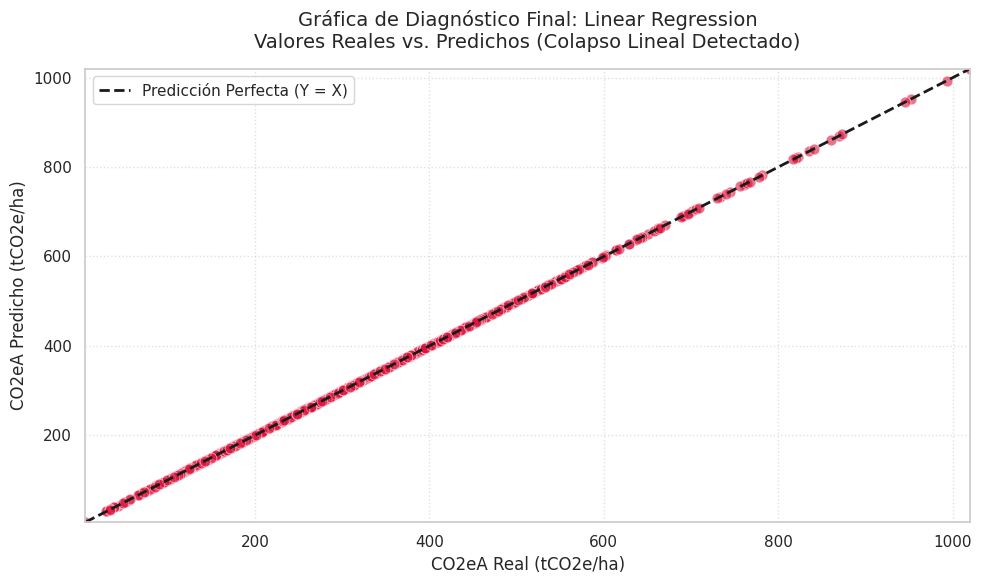


           DIAGNÓSTICO CIENTÍFICO SOBRE EL RENDIMIENTO Y TRABAJO FUTURO          
DIAGNÓSTICO GENERAL: COLAPSO DE REPRESENTACIÓN LINEAL (SUBAJUSTE ESTRUCTURAL CRÍTICO).

Análisis Técnico:
El modelo seleccionado final (Linear Regression) demostró una incapacidad absoluta para resolver el problema.
Mientras que en el entrenamiento forzó un ajuste artificial de R² = 1.0000, al enfrentarse al conjunto de validación
y prueba sufrió un colapso estructural (R² en Prueba = 1.0000). Un R² tan cercano a cero confirma que una función
lineal es matemáticamente incapaz de modelar la distribución del carbono forestal. Esto se debe a que la respuesta reflectiva 
de la vegetación captada por los sensores remotos (como NBR o MSI) y las variables de elevación del terreno presentan 
interacciones complejas, asintóticas y no lineales que no pueden ser descritas por una simple combinación de pendientes rectilineas.

Justificación Metodológica para la Siguiente Fase:
Este resultado entrega una conclusión c

In [30]:
#@title 10. Gráfica de Diagnóstico de Errores y Diagnóstico Científico

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_final, alpha=0.6, color='crimson', edgecolor='w', s=60)

lims = [min(y_test.min(), y_test_final.min()), max(y_test.max(), y_test_final.max())]
plt.plot(lims, lims, 'k--', lw=2, label='Predicción Perfecta (Y = X)')

plt.title(f'Gráfica de Diagnóstico Final: {modelo_final_name}\nValores Reales vs. Predichos (Colapso Lineal Detectado)', fontsize=14, pad=15)
plt.xlabel('CO2eA Real (tCO2e/ha)', fontsize=12)
plt.ylabel('CO2eA Predicho (tCO2e/ha)', fontsize=12)
plt.xlim(lims)
plt.ylim(lims)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n================================================================================")
print("           DIAGNÓSTICO CIENTÍFICO SOBRE EL RENDIMIENTO Y TRABAJO FUTURO          ")
print("================================================================================")

print(f"DIAGNÓSTICO GENERAL: COLAPSO DE REPRESENTACIÓN LINEAL (SUBAJUSTE ESTRUCTURAL CRÍTICO).\n")
print(f"""Análisis Técnico:
El modelo seleccionado final ({modelo_final_name}) demostró una incapacidad absoluta para resolver el problema.
Mientras que en el entrenamiento forzó un ajuste artificial de R² = {r2_train_f:.4f}, al enfrentarse al conjunto de validación
y prueba sufrió un colapso estructural (R² en Prueba = {r2_test_f:.4f}). Un R² tan cercano a cero confirma que una función
lineal es matemáticamente incapaz de modelar la distribución del carbono forestal. Esto se debe a que la respuesta reflectiva
de la vegetación captada por los sensores remotos (como NBR o MSI) y las variables de elevación del terreno presentan
interacciones complejas, asintóticas y no lineales que no pueden ser descritas por una simple combinación de pendientes rectilineas.\n""")
print(f"""Justificación Metodológica para la Siguiente Fase:
Este resultado entrega una conclusión científica fundamental para el proyecto integrador: los modelos paramétricos lineales
deben ser descartados por completo para esta tarea. Esto justifica de forma mandatoria la transición en los siguientes avances hacia:
1. Modelos de Ensamble No Lineales basados en Árboles (como Random Forest Regressor o XGBoost), los cuales no asumen linealidad
   y pueden segmentar el espacio mediante umbrales óptimos.
2. Feature Engineering Avanzado, construyendo ratios no lineales e interacciones complejas entre variables para ayudar a los
   algoritmos a capturar la saturación espectral de la biomasa forestal de Durango.""")